------------------
```markdown
# Copyright © 2025 Meysam Goodarzi
This notebook is licensed under CC BY-NC 4.0 with the following amendments:
- Individuals may use, share, and adapt this material for non-commercial purposes with attribution.
- Institutions/Companies must obtain written consent to use this material, except for nonprofits.
- Commercial use is prohibited without permission.  
Contact: analytica@meysam-goodarzi.com
```
------------------------------
❗❗❗ **IMPORTANT**❗❗❗ **Create a copy of this notebook**

In order to work with this Google Colab you need to create a copy of it. Please **DO NOT** provide your answers here. Instead, work on the copy version. To make a copy:

**Click on: File -> save a copy in drive**

Have you successfully created the copy? if yes, there must be a new tab opened in your browser. Now move to the copy and start from there!

----------------------------------------------


# Probability Foundations & Bayes' Law

## Learning Objectives

By the end of this notebook, you will be able to:
1. Work with probability distributions (PDF, CDF, joint, conditional)
2. Understand and apply Bayes' Law to real problems
3. Implement discrete Bayesian updates in Python
4. Connect probability theory to ABM calibration
5. Understand the difference between aleatory and epistemic uncertainty

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy import stats
import seaborn as sns

# Set random seed for reproducibility
np.random.seed(42)

# Configure plotting
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

## Random Variable
When performing the experiment of flipping a coin (lets denote the experiment by $X$), there are two possible outcomes (events), i.e., *Head* or *Tail*. Let us denote the probability of the coin facing Head and Tail by $P(H)$ and $P(T)$, respectively. We know that $0\leq P(H)\leq 1$ and $0\leq P(T)\leq 1.$ In probability theory, it is said that the random variable $X$ (experiment) has two possible events (outcomes) each with probability $P(X=H)$ and $P(X=T).$

In [ ]:
# The following data is the outcome of an experiment where we flip an UNFAIR coin 20 times. Calculate the probability of each possible event.
X = ["H", "H", "T", "H", "H", "T", "T", "H", "H", "H",
     "H", "H", "T", "H", "T", "T", "T", "H", "H", "H"]
P_H = sum([event=="H" for event in X])/len(X)
P_T = sum([event=="T" for event in X])/len(X)
print(P_H, P_T)

0.65 0.35


We can extend the same concept for experiments with more events, e.g., rolling a die. Here, we can write $P(X=1), \cdots, P(X=6).$ For the sake of simplicity we can denote each possible outcome by $x_i$ with $i=1, \cdots, 6.$ Therefore, the probability of each event $i$ when performing the experiment $X$ is denoted by $P(X=x_i).$

In [ ]:
# The following data is the outcome of an experiment where we roll a die 30 times. Calculate the probability of each possible event.
X = [1, 5, 4, 6, 4, 2, 4, 6, 5, 2,
     3, 1, 4, 6, 3, 1, 2, 3, 1, 3,
     6, 3, 2, 5, 4, 1, 5, 2, 4, 6]
P_xi = []
for i in range(1, 7):
  P_xi += [sum([event==i for event in X])/len(X)]
print(P_xi)


[0.16666666666666666, 0.16666666666666666, 0.16666666666666666, 0.2, 0.13333333333333333, 0.16666666666666666]


#### Exercise 1
Plot the figure where you have the possible events on the x axis and their probability on the y axis.

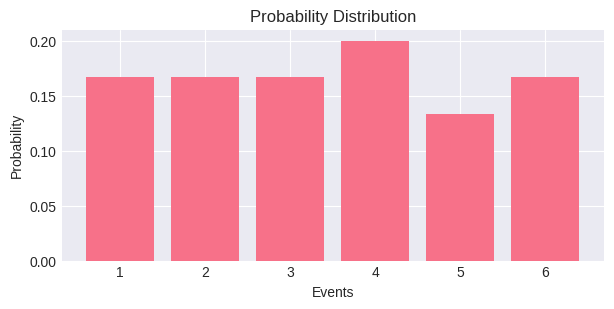

In [ ]:
fig, ax = plt.subplots(figsize=(7, 3))
events = range(1, 7)
ax.bar(events, P_xi)
ax.set(title="Probability Distribution", xlabel="Events", ylabel="Probability")
plt.show()

## Probability Distribution Function (PDF)
Probability Distribution Function (PDF) of a random variable $X$ is a function $f_X(.)$ which maps each possible event $x_i$ to its corresponding probability $P(x_i)$. It is also oftentimes called Probability Mass Function (PMF) in the case of a descrete random variable. In the above cases:
$$f_X(x) = \begin{cases} 0.65 & if\ x=H \\ 0.35 & if\ x=T \end{cases}$$
and
$$f_X(x) = \begin{cases} 0.17 & if\ x=1 \\
                        0.17 & if\ x=2 \\
                        0.17 & if\ x=3 \\
                        0.2 & if\ x=4 \\
                        0.13 & if\ x=5 \\
                        0.16 & if\ x=6 \\
\end{cases}$$




**Coding Quiz**: Create a list/array of the same size as P_xi. Fill each elemet by sum of the corresponding element in P_xi and all the smaller elements. For example, if P_xi = [0.5, 0.3, 0.2], then new_array = [0.5, 0.5+0.3, 0.5+0.3+0.2].

In [ ]:
CP_xi = []
for i in range(len(P_xi)):
  CP_xi += [sum(P_xi[0:i+1])]
print(CP_xi)

[0.16666666666666666, 0.3333333333333333, 0.5, 0.7, 0.8333333333333333, 1.0]


## Cumulative Distribution Function (CDF)
Cumulative Distribution Function (CDF) of a random variable $X$ is a function $F_X(.)$ which maps each possible event $x_i$ to its corresponding cumulative probability calculated as $P(X\leq x_i),$ i.e., the probability that the outcome of RV (experiment) X is less than or equal to $x_i.$

In the above case:
$$F_X(x) = \begin{cases} 0.17 & if\ x=1 \\
                        0.34 & if\ x=2 \\
                        0.51 & if\ x=3 \\
                        0.71 & if\ x=4 \\
                        0.84 & if\ x=5 \\
                        1.00 & if\ x=6 \\
\end{cases}$$

**IMPORTANT**: As you can see the following relationship holds between PDF/PMF and CDF:
For PMF-CDF relationship, we have:
$$F_X(x) = \sum_{x=0}^x f_X(x)$$

and for PDF-CDF relationship, we can write:
$$F_X(x) = \int_{-\infty}^x f_X(x)dx$$ or alternatively
$$f_X(x) = \frac{d}{dx}F_X(x).$$

**Quiz:** What does $F^{-1}(p)$ represent?

**Hint:** think about numerical examples such as $F^{-1}(0.25)$ and $F^{-1}(0.5).$

#### Exercise 2
Create a variable which indicates the quantile each student's average grade in period 1 belongs to, i.e. avg_t1_q (assume 4 quantiles).

In [ ]:
# Import the RCT dataset
df = pd.read_csv("https://drive.google.com/uc?id=1znf0o6-4IqQ7EtvRCZxVYtjUjBNCmZuP")
df['avg_t1_q'] = pd.qcut(df['avg_t1'], q=4, labels=['Q1', 'Q2', 'Q3', 'Q4'])

## Expected Value
The expected value of a random variable is the average value it would have if we took an infinite number of samples of it and then averaged those samples together. Equivalently we can say:
$$\mathbb{E}(X) = \sum_{i=1}^N x_iP(x_i)$$
where $p_i$ denotes the relative proportion of samples with value $x_i$.

Expected Value = -8.326672684688674e-17 
 Mean = 0.0


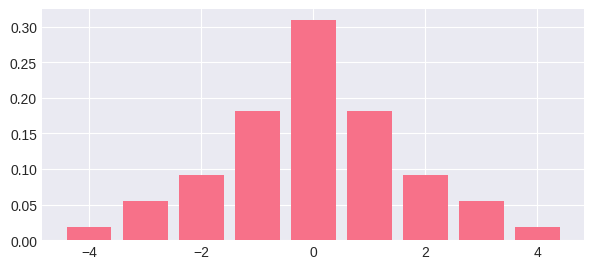

In [ ]:
# plot is the probibility distribution of the following data
X = np.array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
              -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
              1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
              -2, -2, -2, -2, -2,
              2, 2, 2, 2, 2,
              -3, -3, -3,
              3, 3, 3,
              -4, 4])
values, counts = np.unique(X, return_counts=True)
fig, ax = plt.subplots(figsize=(7, 3))
ax.bar(values, counts/len(X))

# Compute the expected value using the formula above and the mean using the python function np.mean()
mean_python = np.mean(X)
expected_value = 0
for i, j in zip(values, counts):
  p_xi = j/len(X)
  expected_value += i*p_xi
print("Expected Value =", expected_value, "\n", "Mean =", mean_python)


## Variance
The variance is the expected value for how much the
sample space $X$ varies from the mean. Equivalently we can say:
$$VAR(X) = \mathbb{E}[(X-\mu)^2]$$ with $\mu$ being $\mu = \mathbb{E}(X)$. Typically $VAR(X)$ is denoted by $\sigma^2$ and is calculated as $$\sigma^2 = \frac{1}{N}\sum_{i=1}^N (x_i-\mu)^2.$$ The parameter $\sigma$ is called standard deviation.

In [ ]:
# Calculate the variance of X
sum_square = 0
for i in X:
  sum_square += (i-expected_value)**2
variance_formula = 1/len(X)*sum_square
variance_python = np.var(X)
print("Variance (mean of sum-squared) =", variance_formula, "\n", "Variance(python) =", variance_python)

Variance (mean of sum-squared) = 2.6545454545454543 
 Variance(python) = 2.6545454545454548


## Gaussian (Normal) Distribution
A Gaussian distribution is a continuous probability distribution that is fully
described with two parameters, the mean ($\mu$) and the variance ($\sigma^2$). It is defined as
$$f_X(x) = \frac{1}{\sqrt{2\pi\sigma^2}}e^{-\frac{(x-\mu)^2}{2\sigma^2}}.$$
There are alternative notations such as
$X \sim \mathcal{N}(\mu, \sigma^2)$ or $X \sim \mathcal{N}(x|\mu, \sigma^2)$.

<!--
# Copyright © 2024 Meysam Goodarzi
This notebook is licensed under CC BY-NC 4.0 with the following amandments:
- Individuals may use, share, and adapt this material for non-commercial purposes with attribution.
- Institutions/Companies must obtain written consent to use this material, except for nonprofits.
- Commercial use is prohibited without permission.  
Contact: analytica@meysam-goodarzi.com.
-->

Mean = 0.7531639480000001 
 Variance = 3.291392248043153 
---------


(array([1., 3., 4., 5., 9., 9., 8., 4., 4., 3.]),
 array([-3.58164733, -2.76401783, -1.94638834, -1.12875884, -0.31112935,
         0.50650015,  1.32412965,  2.14175914,  2.95938864,  3.77701813,
         4.59464763]),
 <BarContainer object of 10 artists>)

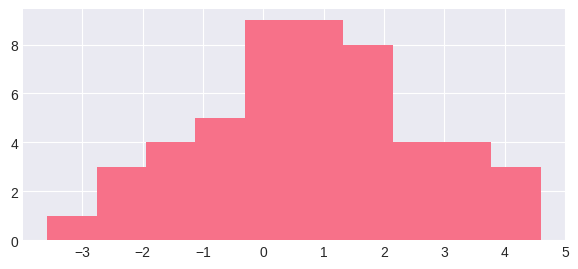

In [ ]:
# Plot the histogram of the following data
X = np.array([-0.64803536,  1.66664278, -3.58164733,  0.89998545,  1.62406002, -2.57298333,
  3.22436883,  1.95584301,  1.49037333, -2.41067398,  2.20394213,  3.88135545,
 -0.76729498,  0.07916849,  1.03565913,  2.88753066,  0.53484251,  2.00084301,
 -1.3125664,  3.76991427, -1.29491141,  0.1934997,  -1.21259305, -0.63283225,
  4.03442483,  1.81498421, -0.22410048,  1.90919324,  0.63397913,  1.47055774,
 -0.88504916,  0.71517192,  0.19569567,  0.79177696,  0.20603178, -1.24203431,
  0.34018339,  0.62462938,  4.59464763,  2.96896777, -2.50783614, -0.25056027,
  2.63913303,  0.13910112,  1.1671937,  -0.79290013,  2.47623536,  3.03226744,
  0.58648688,  0.20552603])
print("Mean =", X.mean(), "\n", "Variance =", X.var(), "\n---------")

fig, ax = plt.subplots(figsize=(7, 3))
plt.hist(X)

#### Exercise 3
Calculate the mean and varince of the random variable Z = 2*X - 3. What do you understand from it?

In [ ]:
Z = 2*X - 3
print("Mean =", Z.mean(), "\n", "Variance =", Z.var())

# Z = (X + X) - 3 --> this is WRONG, 2*X is NOT equal to X + X because Xs are two vectors both having the same distribution, BUT
# not necessarily same outcomes, you can run experiment X 100 times and put it in a vector, then run it another 100 times and put it
# in another vector, so both are gonna be X (from the same RV and distribution) but values are not equal, if you write it in
# the following way, it's more clear
# I: Z = 2*np.random.normal(mu, std, size) - 3
# II: Z = np.random.normal(mu, std, size) + np.random.normal(mu, std, size) - 3
# Clearly Z in I and II will not be equal.
# np.random.normal(mu, std, size) --> generates a data vector of size=size.
# The generated data has the Gaussian distribution with parameters mu and std.

# If Z = X + Y, then Z is distributed as N(mu_X + mu_Z, sigma_X^2 + sigma_Y^2)
# And if Z = a*X then Z is distributed as N(a*mu_X, (a*sigma_X)^2)

Mean = -1.4936721039999998 
 Variance = 13.165568992172611


## Conditional Probability
We define the conditional probability of event $X=x_i$, given that event $Y=y_i$ is true as:
$$P(X=x_i|Y=y_i) = \frac{P(X=x_i, Y=y_i)}{P(Y=y_i)},$$
where
$$P(X=x_i, Y=y_i) = P(X=x_i\land Y=y_i).$$
We can formulate the above symbol as the **probability that:**

**Event $X=x_i$ and event $Y=y_i$ happen** or \\
**Event $Y=y_i$ and event $X=x_i$ happen** or \\
**Event $X=x_i$ happens and then event $Y=y_i$ happens given that event $X=x_i$ has happened** or \\
**Event $Y=y_i$ happens and then event $X=x_i$ happens given that event $Y=y_i$ has happened**.

All above definitions are equivalent.


### Joint Probability Distribution Function (Joint PDF)
In the definitions above, if we obtain the values for each possible pair of events, i.e., the $P(X=x_i, Y=y_i)$ for all $i = 1, \cdots, N,$ we obtain a function which we call Joint PDF of random variables $X$ and $Y.$

### Independence
Two random variables $X$ and $Y$ are called independent if $P(X, Y) = P(X)P(Y),$ i.e., knowledge about $X$ does not provide any knowledge about $Y$ and vice versa.


**Quiz**: What would $P(Z|X, Y)$ turn into if we know that $X$ and $Y$ are independent?

#### Example
If $X$ and $Y$ are random variable representing an experiment where we roll a die and fliping an unfair coin, respectively, then the joint PDF is:

Y (coin)\X (die) --> | X=x_1 (=1) | X=x_2 (=2) | X=x_3 (=3) | X=x_4 (=4) | X=x_5 (=5) | X=x_6 (=6)
 :- | -: | :-: |  :-: | :-: | :-: | :-:
  $Y=y_1 (=H)$ | $p(x_1, y_1)$ | $p(x_2, y_1)$ | $p(x_3, y_1)$ | $p(x_4, y_1)$ | $p(x_5, y_1)$ | $p(x_6, y_1)$
  $Y=y_2 (=T)$ | $p(x_1, y_2)$ | $p(x_2, y_2)$ | $p(x_3, y_2)$ | $p(x_4, y_2)$ | $p(x_5, y_2)$ | $p(x_6, y_2)$

In [ ]:
# Example: Disease testing
# Two random variables: D (disease status), T (test result)

# Define joint probability table
joint_prob = pd.DataFrame({
    'Test +': [0.009, 0.0495],  # P(D=1, T=1), P(D=0, T=1)
    'Test -': [0.001, 0.9405]   # P(D=1, T=0), P(D=0, T=0)
}, index=['Disease', 'No Disease'])

print("Joint Probability Table P(D, T):")
print(joint_prob)
print(f"\nSum of all probabilities: {joint_prob.values.sum():.3f} (should be 1.0)")

# Marginal probabilities
print("\n" + "="*50)
print("Marginal Probabilities:")
prob_disease = joint_prob.loc['Disease', :].sum()
prob_test_positive = joint_prob.loc[:, 'Test +'].sum()
print(f"P(Disease) = {prob_disease:.3f}")
print(f"P(Test +) = {prob_test_positive:.3f}")

# Conditional probabilities
print("\n" + "="*50)
print("Conditional Probabilities:")
# P(Test + | Disease) = P(Disease, Test +) / P(Disease)
prob_test_pos_given_disease = joint_prob.loc['Disease', 'Test +'] / prob_disease
print(f"P(Test + | Disease) = {prob_test_pos_given_disease:.3f} (sensitivity)")

# P(Disease | Test +) = P(Disease, Test +) / P(Test +)
prob_disease_given_test_pos = joint_prob.loc['Disease', 'Test +'] / prob_test_positive
print(f"P(Disease | Test +) = {prob_disease_given_test_pos:.3f} (posterior)")

Joint Probability Table P(D, T):
            Test +  Test -
Disease     0.0090  0.0010
No Disease  0.0495  0.9405

Sum of all probabilities: 1.000 (should be 1.0)

Marginal Probabilities:
P(Disease) = 0.010
P(Test +) = 0.059

Conditional Probabilities:
P(Test + | Disease) = 0.900 (sensitivity)
P(Disease | Test +) = 0.154 (posterior)


## Bayes' Law
Bayes theorem tells us how to compute the probability of an event given information about another event. It can be directly derived from the conditional probability rule and can be written as:
$$P(X=x_i|Y=y_i) = \frac{P(Y=y_i|X=x_i)P(X=x_i)}{P(Y=y_i)}.$$

What does that mean?

### Bayesian Terminology

Let $\theta$ = hypothesis/parameter, $D$ = data/evidence:

$$P(\theta | D) = \frac{P(D | \theta) \cdot P(\theta)}{P(D)}$$

Where:
- $P(\theta | D)$ = **Posterior**: Updated belief after seeing data
- $P(D | \theta)$ = **Likelihood**: How probable is the data given the hypothesis
- $P(\theta)$ = **Prior**: Initial belief before seeing data
- $P(D)$ = **Evidence**: Normalizing constant (marginal likelihood)

### The Medical Testing Problem

**Scenario**: A rare disease affects 1% of the population. A test is 90% accurate (both for sick and healthy people).

**Question**: If you test positive, what's the probability you have the disease?

**Given**:
- $P(\text{Disease}) = 0.01$ (prior/prevalence)
- $P(\text{Test +} | \text{Disease}) = 0.90$ (sensitivity)
- $P(\text{Test -} | \text{No Disease}) = 0.90$ (specificity)

**Want**: $P(\text{Disease} | \text{Test +})$ (posterior)

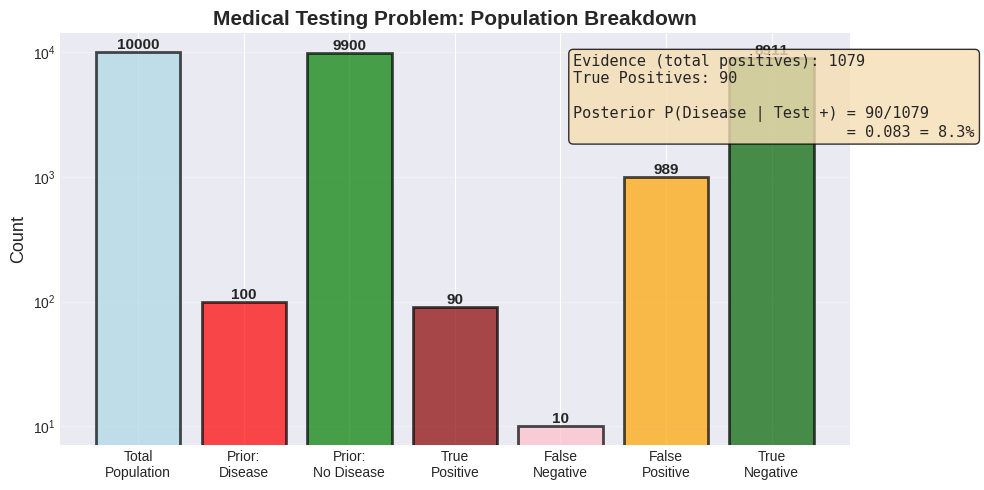


POSTERIOR: P(Disease | Test +) = 0.083 or 8.3%

Despite a 90% accurate test, a positive result only gives
a 8.3% chance of having the disease!

Why? The prior P(Disease) is very low (1%), so false positives
from the large healthy population swamp the true positives.


In [ ]:
# Medical testing problem - visual solution

# Population of 10,000 people
population = 10000
prior_disease = 0.01  # P(Disease)
sensitivity = 0.90  # P(Test + | Disease)
specificity = 0.90  # P(Test - | No Disease)

# Calculate counts
n_disease = int(population * prior_disease)  # 100
n_no_disease = population - n_disease  # 9,900

true_positives = int(n_disease * sensitivity)  # 90
false_negatives = n_disease - true_positives  # 10
false_positives = int(n_no_disease * (1 - specificity))  # 990
true_negatives = n_no_disease - false_positives  # 8,910

total_positives = true_positives + false_positives  # marginal count of positive tests

# Posterior via Bayes' theorem: P(Disease | Test+) = P(Test+|Disease) * P(Disease) / P(Test+)
posterior = true_positives / total_positives

# Visualize
fig, ax = plt.subplots(figsize=(10, 5))

categories = ['Total\nPopulation', 'Prior:\nDisease', 'Prior:\nNo Disease',
              'True\nPositive', 'False\nNegative', 'False\nPositive', 'True\nNegative']
counts = [population, n_disease, n_no_disease,
          true_positives, false_negatives, false_positives, true_negatives]
colors = ['lightblue', 'red', 'green', 'darkred', 'pink', 'orange', 'darkgreen']

bars = ax.bar(categories, counts, color=colors, alpha=0.7, edgecolor='black', linewidth=2)

for bar, count in zip(bars, counts):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{count}', ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_ylabel('Count', fontsize=13)
ax.set_title('Medical Testing Problem: Population Breakdown', fontsize=15, fontweight='bold')
ax.set_yscale('log')
ax.grid(True, alpha=0.3, axis='y')

textstr = (f'Evidence (total positives): {total_positives}\n'
           f'True Positives: {true_positives}\n'
           f'\nPosterior P(Disease | Test +) = {true_positives}/{total_positives}\n'
           f'                              = {posterior:.3f} = {posterior*100:.1f}%')
props = dict(boxstyle='round', facecolor='wheat', alpha=0.8)
ax.text(0.65, 0.95, textstr, transform=ax.transAxes, fontsize=11,
        verticalalignment='top', bbox=props, family='monospace')

plt.tight_layout()
plt.show()

print(f"\n{'='*60}")
print(f"POSTERIOR: P(Disease | Test +) = {posterior:.3f} or {posterior*100:.1f}%")
print(f"{'='*60}")
print(f"\nDespite a 90% accurate test, a positive result only gives")
print(f"a {posterior*100:.1f}% chance of having the disease!")
print(f"\nWhy? The prior P(Disease) is very low (1%), so false positives")
print(f"from the large healthy population swamp the true positives.")

### Using Bayes' Law with Law of Total Probability

When we don't know $P(D)$ directly, we can compute it using the **Law of Total Probability**:

$$P(D) = \sum_{\theta} P(D | \theta) \cdot P(\theta)$$

For the medical problem:

$$P(\text{Test +}) = P(\text{Test +} | \text{Disease}) \cdot P(\text{Disease})$$
$$+ P(\text{Test +} | \text{No Disease}) \cdot P(\text{No Disease})$$

In [ ]:
# Medical testing - analytical calculation using Bayes' theorem

prior_disease = 0.01  # P(Disease)
prior_no_disease = 0.99  # P(No Disease)

likelihood_pos_given_disease = 0.90  # P(Test + | Disease) — sensitivity
likelihood_pos_given_no_disease = 0.10  # P(Test + | No Disease) — 1 - specificity

# Step 1: Evidence = P(Test +) via Law of Total Probability
evidence = (likelihood_pos_given_disease * prior_disease +
            likelihood_pos_given_no_disease * prior_no_disease)

print("Step 1: Evidence P(Test +) via Law of Total Probability")
print(f"P(Test +) = P(Test + | Disease)    × P(Disease)")
print(f"          + P(Test + | No Disease) × P(No Disease)")
print(f"         = {likelihood_pos_given_disease} × {prior_disease}")
print(f"          + {likelihood_pos_given_no_disease} × {prior_no_disease}")
print(f"         = {evidence:.4f}")

# Step 2: Posterior via Bayes' theorem
# P(Disease | Test +) = likelihood * prior / evidence
posterior = (likelihood_pos_given_disease * prior_disease) / evidence

print(f"\nStep 2: Posterior via Bayes' Theorem")
print(f"P(Disease | Test +) = likelihood × prior / evidence")
print(f"                    = P(Test + | Disease) × P(Disease) / P(Test +)")
print(f"                    = {likelihood_pos_given_disease} × {prior_disease} / {evidence:.4f}")
print(f"                    = {posterior:.4f}")
print(f"\n{'='*60}")
print(f"POSTERIOR: P(Disease | Test +) = {posterior:.3f} or {posterior*100:.1f}%")
print("="*60)

Step 1: Evidence P(Test +) via Law of Total Probability
P(Test +) = P(Test + | Disease)    × P(Disease)
          + P(Test + | No Disease) × P(No Disease)
         = 0.9 × 0.01
          + 0.1 × 0.99
         = 0.1080

Step 2: Posterior via Bayes' Theorem
P(Disease | Test +) = likelihood × prior / evidence
                    = P(Test + | Disease) × P(Disease) / P(Test +)
                    = 0.9 × 0.01 / 0.1080
                    = 0.0833

POSTERIOR: P(Disease | Test +) = 0.083 or 8.3%


### Sequential Bayesian Updating

One beautiful property of Bayes' Law: **Today's posterior = tomorrow's prior**

After observing data $D_1$:
$$P(\theta | D_1) = \frac{P(D_1 | \theta) \cdot P(\theta)}{P(D_1)}$$

After observing more data $D_2$:
$$P(\theta | D_1, D_2) = \frac{P(D_2 | \theta) \cdot \color{red}{P(\theta | D_1)}}{P(D_2 | D_1)}$$

**Application**: Agents in ABMs can update beliefs as they observe neighbors over time.

Initial prior: P(Disease) = 0.0100

Sequential Bayesian updates:
--------------------------------------------------
After test 1 (positive): posterior P(Disease | data) = 0.0833
After test 2 (positive): posterior P(Disease | data) = 0.4500
After test 3 (negative): posterior P(Disease | data) = 0.0833
After test 4 (positive): posterior P(Disease | data) = 0.4500


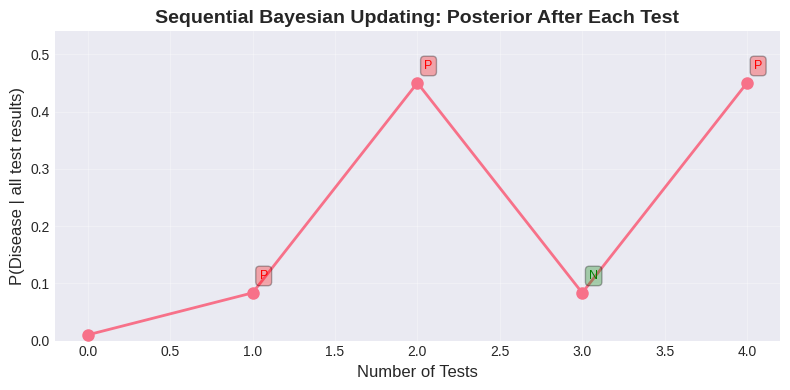


Final posterior after all tests: P(Disease | data) = 0.4500


In [ ]:
# Sequential Bayesian updating: multiple tests

def bayesian_update(prior: float, likelihood_given_disease: float, likelihood_given_no_disease: float) -> float:
    """Perform one Bayesian update.

    Args:
        prior: P(Disease) before this observation
        likelihood_given_disease: P(observed result | Disease)
        likelihood_given_no_disease: P(observed result | No Disease)

    Returns:
        posterior: P(Disease | observed result)
    """
    # Evidence via Law of Total Probability
    evidence = likelihood_given_disease * prior + likelihood_given_no_disease * (1 - prior)
    # Bayes' theorem: posterior = likelihood * prior / evidence
    posterior = (likelihood_given_disease * prior) / evidence
    return posterior


prior_disease = 0.01  # initial prior P(Disease)
sensitivity = 0.90  # P(Test + | Disease)
specificity = 0.90  # P(Test - | No Disease)

test_results = ['positive', 'positive', 'negative', 'positive']

beliefs = [prior_disease]
current_prior = prior_disease

print(f"Initial prior: P(Disease) = {prior_disease:.4f}\n")
print("Sequential Bayesian updates:")
print("-" * 50)

for i, result in enumerate(test_results, 1):
    if result == 'positive':
        current_prior = bayesian_update(current_prior, sensitivity, 1 - specificity)
    else:
        current_prior = bayesian_update(current_prior, 1 - sensitivity, specificity)

    beliefs.append(current_prior)
    print(f"After test {i} ({result:8s}): posterior P(Disease | data) = {current_prior:.4f}")

# Visualise belief evolution
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(range(len(beliefs)), beliefs, 'o-', linewidth=2, markersize=8, label='Posterior belief')
ax.set_xlabel('Number of Tests', fontsize=12)
ax.set_ylabel('P(Disease | all test results)', fontsize=12)
ax.set_title('Sequential Bayesian Updating: Posterior After Each Test', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)

for i, result in enumerate(test_results, 1):
    color = 'red' if result == 'positive' else 'green'
    ax.annotate(result[0].upper(), xy=(i, beliefs[i]), xytext=(5, 10),
                textcoords='offset points', fontsize=9, color=color,
                bbox=dict(boxstyle='round,pad=0.3', facecolor=color, alpha=0.3))

ax.set_ylim([0, max(beliefs) * 1.2])
plt.tight_layout()
plt.show()

print(f"\nFinal posterior after all tests: P(Disease | data) = {current_prior:.4f}")

## Exercises 1

A very rare disease affects 0.1% of the population (1 in 1000). A test for this disease is 99% accurate (both sensitivity and specificity).

**Questions**:
1. If you test positive, what's the probability you have the disease?
2. How does this compare to the medical testing problem we solved earlier?
3. What does this tell you about the importance of prior probability?

**Hint**: Follow the same steps as the medical testing problem.

In [ ]:
# Your code here


## Exercise 2

You have three hypotheses about a coin:
- $H_1$: Fair coin ($p = 0.5$)
- $H_2$: Slightly biased ($p = 0.6$)
- $H_3$: Heavily biased ($p = 0.8$)

Your prior beliefs: $P(H_1) = 0.7$, $P(H_2) = 0.2$, $P(H_3) = 0.1$

You flip the coin 10 times and get 7 heads.

**Questions**:
1. Calculate the likelihood $P(\text{7 heads} | H_i)$ for each hypothesis
2. Calculate the posterior $P(H_i | \text{7 heads})$ for each hypothesis
3. Which hypothesis is most likely after seeing the data?
4. Visualize the prior and posterior distributions

In [ ]:
# Your code here


## Exercise 3

Extend the sequential updating example to explore how many positive tests in a row would be needed to be 95% confident of having the disease.

**Starting conditions**:
- Prior: 1% disease prevalence
- Test accuracy: 90% sensitivity, 90% specificity

**Task**: Simulate sequential positive tests and plot how belief evolves until it crosses 0.95.

In [ ]:
# Your code here


**Congratulations! You have finished the Notebook! Great Job!**
🤗🙌👍👏💪
<!--
# Copyright © 2025 Meysam Goodarzi
This notebook is licensed under CC BY-NC 4.0 with the following amandments:
- Individuals may use, share, and adapt this material for non-commercial purposes with attribution.
- Institutions/Companies must obtain written consent to use this material, except for nonprofits.
- Commercial use is prohibited without permission.  
Contact: analytica@meysam-goodarzi.com.
-->